<a href="https://colab.research.google.com/github/preesr/quantum-computing/blob/main/Deutsch_Jozsa_Algorithm_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit # Need this to build quantum programs, define qubits, and perform operations
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager # for optimizing the hardware

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService #ibm runtime service in IBM cloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/54

In [3]:
from qiskit import __version__

print(__version__)

2.5.2


In [4]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

In [6]:
"""
Deutsch-Jozsa extends Deutsch but for n bits instead of just 1 bit.
Still needs just a single query.
The below generates a random query gate function. Deutsch was just parity query
gate function
"""
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.

    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance for balanced
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string): # This is NOT a CNOT function
    # encodes a classical bit string into the corresponding quantum basis state
    # these enumeration and reversing are about accounting for qiskit
    # little endian ordering
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc

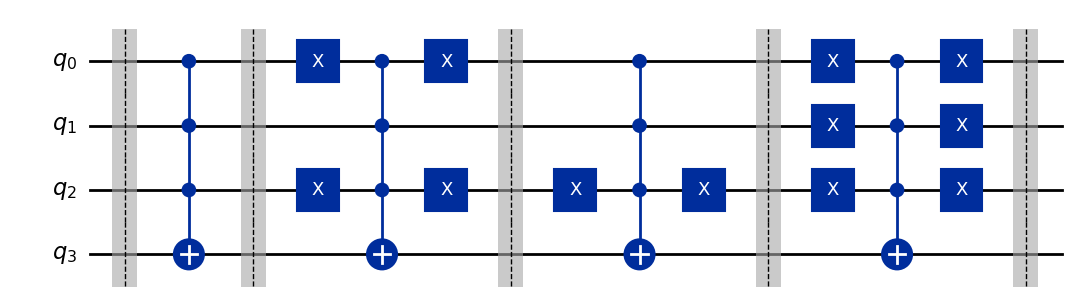

In [20]:
display(dj_query(3).draw(output="mpl")) # you see different circuits during different runs because
# the functions are randomly generated. 4 qubits due to n+1

In [21]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm. Takes the
    # quantum circuit as the argument

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n) # it is the physical initialization step required to get the bottom qubit into the |1> state because
    # physical hardware and simulators initialize every qubit to |0>
    qc.h(range(n + 1)) # applies hadamard on each till n+1
    qc.compose(function, inplace=True) # combine or append one quantum circuit (or instruction) onto another
    qc.h(range(n)) # applies hadamard on all except |1>
    qc.measure(range(n), range(n))
    return qc

In [22]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

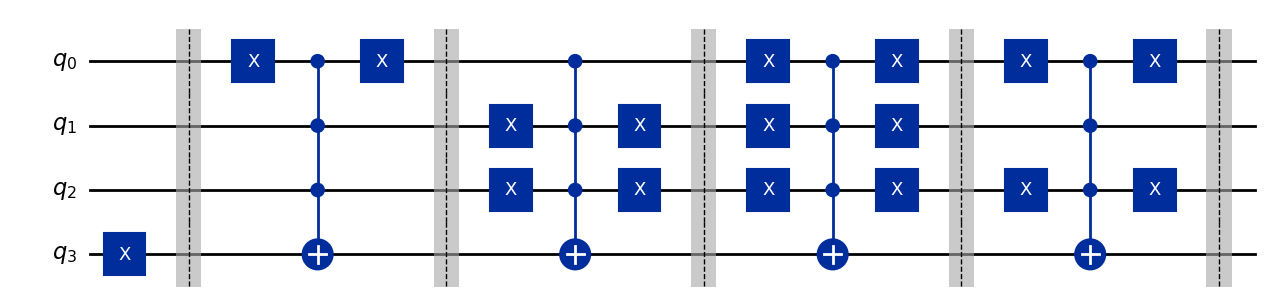

'balanced'

In [24]:
f = dj_query(3) # passing the total number of qubits
display(f.draw("mpl"))
display(dj_algorithm(f))

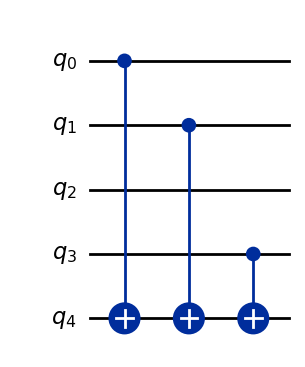

In [27]:
def bv_query(s):
    # Create a quantum circuit implementing a query gate for the
    # Bernstein-Vazirani problem: Deutsch Jozsa only determines whether function
    # is constant or balanced but BZ problem is to identify the entire hidden
    # bitstring s.
    qc = QuantumCircuit(len(s) + 1)
    # these enumeration and reversing are about accounting for qiskit
    # little endian ordering
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s)) # performs binary dot product
    return qc


display(bv_query("1011").draw(output="mpl"))

In [29]:
def bv_algorithm(function: QuantumCircuit):
  # BV problem is simply using DJ algorithm
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]


display(bv_algorithm(function=bv_query("1011")))
# displays the bitstring identified

'1011'